# Exploratory Data Analysis

This notebook performs detailed exploratory data analysis on the training data to understand the data, identify patterns and issues, and guide feature engineering and model selection.

## 1. Load the Training Data

I load only the training split for the exploratory data analysis to avoid using validation or test data during analysis.

In [1]:
import pandas as pd

# Load only the training data
train = pd.read_csv("../artifacts/train.csv")

print("Training shape:", train.shape)

Training shape: (67533, 28)


## 2. Data Types, Shape, and Memory

I inspect the data types, dataset size, and memory usage to understand the structure of the training data.

In [2]:
# Check data types
train.dtypes

order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
item_count                       float64
total_price                      float64
total_freight                    float64
payment_count                    float64
total_payment                    float64
payment_installments             float64
review_count                     float64
average_review_score             float64
customer_unique_id                   str
customer_zip_code_prefix           int64
customer_city                        str
customer_state                       str
seller_zip_code_prefix           float64
seller_city                          str
seller_state                         str
unique_products                  float64
average_product_

In [3]:
# Check memory usage
train.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 67533 entries, 0 to 67532
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       67533 non-null  str    
 1   customer_id                    67533 non-null  str    
 2   order_status                   67533 non-null  str    
 3   order_purchase_timestamp       67533 non-null  str    
 4   order_approved_at              67519 non-null  str    
 5   order_delivered_carrier_date   67532 non-null  str    
 6   order_delivered_customer_date  67533 non-null  str    
 7   order_estimated_delivery_date  67533 non-null  str    
 8   item_count                     67533 non-null  float64
 9   total_price                    67533 non-null  float64
 10  total_freight                  67533 non-null  float64
 11  payment_count                  67532 non-null  float64
 12  total_payment                  67532 non-null  float64
 1

## 3. Identify Column Types

I categorize the columns into numerical, categorical, date, text, and identifier fields to understand how each type should be analyzed.

In [4]:
# Identify numerical and categorical columns

numerical_cols = train.select_dtypes(include="number").columns.tolist()

categorical_cols = train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical / other columns:", categorical_cols)

Numerical columns: ['item_count', 'total_price', 'total_freight', 'payment_count', 'total_payment', 'payment_installments', 'review_count', 'average_review_score', 'customer_zip_code_prefix', 'seller_zip_code_prefix', 'unique_products', 'average_product_weight', 'average_product_photos', 'delivery_days']
Categorical / other columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_city', 'customer_state', 'seller_city', 'seller_state', 'delivery_label']


## 4. Identify Dates, IDs, and Categorical Columns

I separate date, identifier, and categorical columns to prepare them for the appropriate EDA analysis.

In [5]:
# Define the main column types

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

id_cols = [
    "order_id",
    "customer_id",
    "customer_unique_id"
]

categorical_cols = [
    "order_status",
    "customer_city",
    "customer_state",
    "delivery_label"
]

print("Date columns:", date_cols)
print("ID columns:", id_cols)
print("Categorical columns:", categorical_cols)

Date columns: ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
ID columns: ['order_id', 'customer_id', 'customer_unique_id']
Categorical columns: ['order_status', 'customer_city', 'customer_state', 'delivery_label']


## 5. Missing Values

I check the training data for missing values and identify which columns contain missing data.

In [6]:
# Count missing values in each column
missing_values = train.isnull().sum()

# Show only columns with missing values
missing_values[missing_values > 0]

order_approved_at                 14
order_delivered_carrier_date       1
payment_count                      1
total_payment                      1
payment_installments               1
review_count                     515
average_review_score             515
average_product_weight            16
average_product_photos          1197
dtype: int64

## 6. Numerical Statistics

I examine summary statistics for the numerical features to understand their ranges, central values, and variability.

In [7]:
# Summary statistics for numerical columns
train[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
item_count,67533.0,1.142079,0.541635,1.000000,1.000000,1.000000,1.000000,21.000000
total_price,67533.0,135.884499,205.187627,2.290000,45.900000,85.000000,149.900000,13440.000000
total_freight,67533.0,22.244256,19.999582,0.000000,14.100000,16.790000,23.700000,1002.290000
payment_count,67532.0,1.047622,0.397212,1.000000,1.000000,1.000000,1.000000,26.000000
total_payment,67532.0,158.167657,214.277783,10.070000,61.630000,104.190000,175.485000,13664.080000
payment_installments,67532.0,2.974397,2.755007,1.000000,1.000000,2.000000,4.000000,24.000000
review_count,67018.0,1.007267,0.085635,1.000000,1.000000,1.000000,1.000000,3.000000
average_review_score,67018.0,4.100550,1.319395,1.000000,4.000000,5.000000,5.000000,5.000000
customer_zip_code_prefix,67533.0,36010.131728,29908.266914,1004.000000,12061.000000,25959.000000,60360.000000,99980.000000
seller_zip_code_prefix,67533.0,24810.553004,27817.631046,1001.000000,6506.000000,13912.000000,30180.000000,99730.000000


## 7. Numerical Outliers

I check the numerical features for potential outliers using the IQR method.

In [8]:
# Check potential outliers using the IQR method
Q1 = train[numerical_cols].quantile(0.25)
Q3 = train[numerical_cols].quantile(0.75)

IQR = Q3 - Q1

outliers = (
    (train[numerical_cols] < Q1 - 1.5 * IQR) |
    (train[numerical_cols] > Q3 + 1.5 * IQR)
).sum()

outlier_percentage = (outliers / len(train) * 100).sort_values(ascending=False)

outlier_percentage

seller_zip_code_prefix      15.539070
average_product_weight      14.464040
average_review_score        13.799180
item_count                  10.008440
total_freight                9.815942
total_price                  7.938341
total_payment                7.859861
payment_installments         6.925503
delivery_days                5.105652
unique_products              3.272474
payment_count                3.152533
average_product_photos       2.866747
review_count                 0.715206
customer_zip_code_prefix     0.000000
dtype: float64

## 8. Distributions and Skew

I examine the distributions and skewness of the numerical features to identify highly skewed variables.

In [9]:
#%pip install matplotlib

In [10]:
import matplotlib.pyplot as plt

# Check skewness
train[numerical_cols].skew().sort_values(ascending=False)

payment_count               22.420165
review_count                11.886878
total_price                 10.719309
total_payment               10.149896
total_freight                8.584291
item_count                   8.106935
unique_products              7.675360
delivery_days                3.867077
average_product_weight       3.579818
average_product_photos       1.938152
payment_installments         1.592864
seller_zip_code_prefix       1.524194
customer_zip_code_prefix     0.739793
average_review_score        -1.384370
dtype: float64

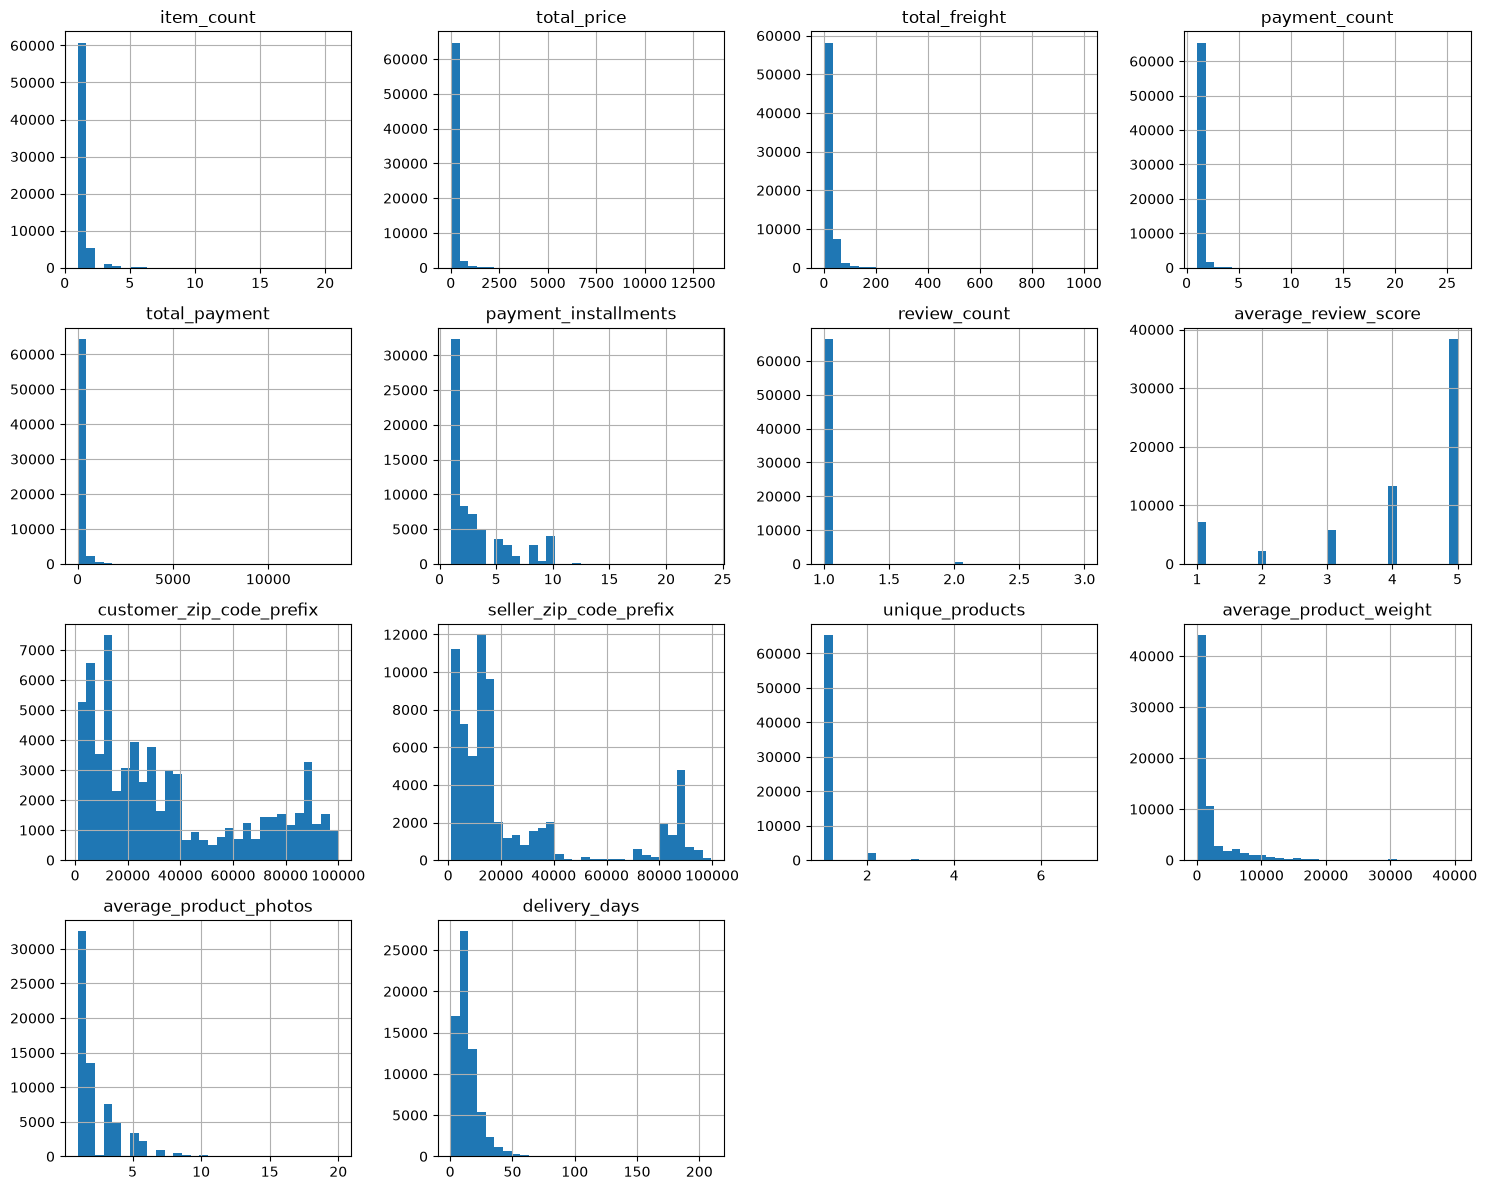

In [11]:
# Plot distributions of numerical features

train[numerical_cols].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

## 9. Categorical Analysis

I examine the value counts of the categorical features to identify dominant, rare, or inconsistent categories.

In [12]:
# Show value counts for categorical features

for col in categorical_cols:
    print(f"\n{col}:")
    print(train[col].value_counts().head(10))


order_status:
order_status
delivered    67527
canceled         6
Name: count, dtype: int64

customer_city:
customer_city
sao paulo                9921
rio de janeiro           4780
belo horizonte           1869
brasilia                 1395
curitiba                 1020
porto alegre              975
campinas                  967
salvador                  823
guarulhos                 724
sao bernardo do campo     622
Name: count, dtype: int64

customer_state:
customer_state
SP    27204
RJ     8967
MG     8130
RS     3912
PR     3461
SC     2577
BA     2307
ES     1445
GO     1409
DF     1404
Name: count, dtype: int64

delivery_label:
delivery_label
On Time    61436
Late        6097
Name: count, dtype: int64


## 10. Categorical Cardinality

I check the number of unique values in each categorical feature to identify high-cardinality columns.

In [13]:
# Count unique values in each categorical column
train[categorical_cols].nunique().sort_values(ascending=False)

customer_city     3747
customer_state      27
order_status         2
delivery_label       2
dtype: int64

## 11. Relationships with the Label

I compare numerical features across the delivery labels to identify differences between Late and On Time orders.

In [14]:
# Compare numerical features by delivery label
train.groupby("delivery_label")[numerical_cols].mean().T

delivery_label,Late,On Time
item_count,1.114319,1.144834
total_price,149.767376,134.506741
total_freight,25.202941,21.950632
payment_count,1.040190,1.048359
total_payment,175.007633,156.496706
payment_installments,3.124672,2.959486
review_count,1.006208,1.007370
average_review_score,2.389933,4.267527
customer_zip_code_prefix,39846.627194,35629.392213
seller_zip_code_prefix,21511.729047,25137.933199


## 12. Numerical Features vs. Label

I visualize selected numerical features by delivery label to identify differences between Late and On Time orders.

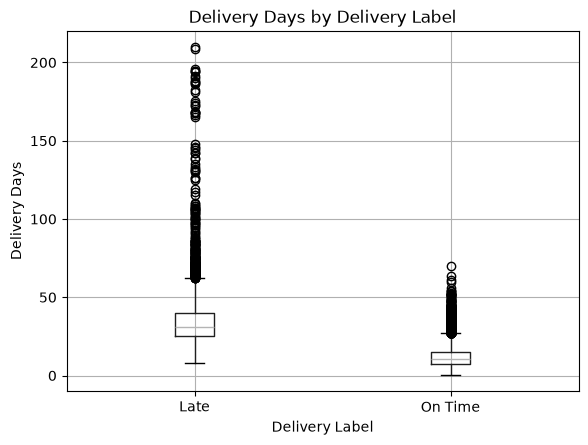

In [15]:
import matplotlib.pyplot as plt

# Compare key numerical features by delivery label
train.boxplot(
    column="delivery_days",
    by="delivery_label"
)

plt.title("Delivery Days by Delivery Label")
plt.suptitle("")
plt.xlabel("Delivery Label")
plt.ylabel("Delivery Days")
plt.show()

## 13. Correlation Analysis

I examine correlations between numerical features to identify strongly related variables.

In [16]:
# Calculate correlations between numerical features
correlation_matrix = train[numerical_cols].corr()

correlation_matrix

,item_count,total_price,total_freight,payment_count,total_payment,payment_installments,review_count,average_review_score,customer_zip_code_prefix,seller_zip_code_prefix,unique_products,average_product_weight,average_product_photos,delivery_days
item_count,1.000000,0.155733,0.475176,-0.003912,0.193599,0.065080,0.014090,-0.122805,-0.004485,-0.010370,0.457178,-0.006800,-0.050010,-0.018415
total_price,0.155733,1.000000,0.414521,0.000037,0.996354,0.310621,-0.010111,-0.036302,0.034031,0.078306,0.056311,0.330830,0.032235,0.056427
total_freight,0.475176,0.414521,1.000000,0.000196,0.490457,0.198555,-0.001407,-0.105056,0.178521,0.103213,0.208000,0.512347,-0.009848,0.182663
payment_count,-0.003912,0.000037,0.000196,1.000000,0.000039,-0.044826,0.006470,-0.001929,-0.012300,-0.004940,0.007668,0.009592,-0.006771,-0.000803
total_payment,0.193599,0.996354,0.490457,0.000039,1.000000,0.316425,-0.009830,-0.044608,0.049319,0.084591,0.073438,0.364738,0.029916,0.071120
payment_installments,0.065080,0.310621,0.198555,-0.044826,0.316425,1.000000,0.021450,-0.028656,0.049296,0.033648,0.068309,0.197193,0.000566,0.048173
review_count,0.014090,-0.010111,-0.001407,0.006470,-0.009830,0.021450,1.000000,-0.003914,0.001719,0.003485,0.025803,-0.009001,-0.024977,0.002074
average_review_score,-0.122805,-0.036302,-0.105056,-0.001929,-0.044608,-0.028656,-0.003914,1.000000,-0.025301,0.030945,-0.101980,-0.028667,0.015553,-0.358209
customer_zip_code_prefix,-0.004485,0.034031,0.178521,-0.012300,0.049319,0.049296,0.001719,-0.025301,1.000000,0.064240,-0.010652,-0.000236,0.018016,0.264174
seller_zip_code_prefix,-0.010370,0.078306,0.103213,-0.004940,0.084591,0.033648,0.003485,0.030945,0.064240,1.000000,-0.010620,0.009417,-0.037701,0.039202


## 14. Categorical Features vs. Label

I compare categorical features with the delivery label to identify categories associated with Late and On Time orders.

In [17]:
# Compare categorical features with the delivery label

for col in ["order_status", "customer_state"]:
    print(f"\n{col}:")
    print(pd.crosstab(train[col], train["delivery_label"], normalize="index").round(3))


order_status:
delivery_label   Late  On Time
order_status                  
canceled        0.167    0.833
delivered       0.090    0.910

customer_state:
delivery_label   Late  On Time
customer_state                
AC              0.045    0.955
AL              0.279    0.721
AM              0.048    0.952
AP              0.059    0.941
BA              0.150    0.850
CE              0.182    0.818
DF              0.080    0.920
ES              0.133    0.867
GO              0.096    0.904
MA              0.215    0.785
MG              0.063    0.937
MS              0.118    0.882
MT              0.086    0.914
PA              0.134    0.866
PB              0.127    0.873
PE              0.119    0.881
PI              0.167    0.833
PR              0.054    0.946
RJ              0.166    0.834
RN              0.123    0.877
RO              0.038    0.962
RR              0.172    0.828
RS              0.087    0.913
SC              0.120    0.880
SE              0.171    0.829
SP     

## 15. Date Analysis

I examine order timing and delivery time patterns to identify temporal effects that may help explain late deliveries.

In [18]:
# Create weekday and month features for EDA
train["purchase_datetime"] = pd.to_datetime(train["order_purchase_timestamp"])

train["purchase_weekday"] = train["purchase_datetime"].dt.day_name()
train["purchase_month"] = train["purchase_datetime"].dt.month

# Compare delivery labels by weekday
pd.crosstab(
    train["purchase_weekday"],
    train["delivery_label"],
    normalize="index"
).round(3)

delivery_label,Late,On Time
purchase_weekday,,
Friday,0.095,0.905
Monday,0.100,0.900
Saturday,0.090,0.910
Sunday,0.084,0.916
Thursday,0.083,0.917
Tuesday,0.093,0.907
Wednesday,0.086,0.914


## 16. Geography Analysis

I examine customer and seller geographic information to identify geographic patterns related to delivery performance.

In [19]:
# Compare delivery labels by customer state
pd.crosstab(
    train["customer_state"],
    train["delivery_label"],
    normalize="index"
).round(3)

delivery_label,Late,On Time
customer_state,,
AC,0.045,0.955
AL,0.279,0.721
AM,0.048,0.952
AP,0.059,0.941
BA,0.150,0.850
CE,0.182,0.818
DF,0.080,0.920
ES,0.133,0.867
GO,0.096,0.904


## 17. Seller Geography

I examine seller state information to identify geographic patterns related to delivery performance.

In [21]:
# Compare delivery labels by seller state
pd.crosstab(
    train["seller_state"],
    train["delivery_label"],
    normalize="index"
).round(3)

delivery_label,Late,On Time
seller_state,,
AM,0.667,0.333
BA,0.064,0.936
CE,0.125,0.875
DF,0.062,0.938
ES,0.075,0.925
GO,0.040,0.960
MA,0.381,0.619
MG,0.062,0.938
MS,0.026,0.974


## 18. ZIP-Code Analysis

I examine customer and seller ZIP-code prefixes to identify geographic patterns related to delivery performance.

In [23]:
# Compare delivery labels by customer ZIP-code prefix
pd.crosstab(
    train["customer_zip_code_prefix"],
    train["delivery_label"],
    normalize="index"
).head(10).round(3)

delivery_label,Late,On Time
customer_zip_code_prefix,,
1004,0.0,1.0
1005,0.0,1.0
1006,0.0,1.0
1007,0.0,1.0
1008,0.0,1.0
1009,0.0,1.0
1011,0.0,1.0
1012,0.0,1.0
1013,0.0,1.0


In [24]:
# Compare delivery labels by seller ZIP-code prefix
pd.crosstab(
    train["seller_zip_code_prefix"],
    train["delivery_label"],
    normalize="index"
).head(10).round(3)

delivery_label,Late,On Time
seller_zip_code_prefix,,
1001.0,0.000,1.000
1021.0,0.207,0.793
1026.0,0.123,0.877
1031.0,0.065,0.935
1035.0,0.125,0.875
1040.0,0.105,0.895
1044.0,0.000,1.000
1123.0,0.111,0.889
1127.0,0.000,1.000


## 19. Delivery Time by Label

I compare delivery time across the delivery labels to identify differences between Late and On Time orders.

In [25]:
# Compare delivery days by label
train.groupby("delivery_label")["delivery_days"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
delivery_label,,,,
Late,34.508173,31.271493,7.772269,209.628611
On Time,11.772115,10.801806,0.533414,70.213611


## 20. Findings Summary

The EDA identified the main data characteristics, missing values, skewed numerical features, potential outliers, categorical patterns, temporal patterns, and geographic information. These findings will guide the feature engineering and model selection in the next notebook.

In [27]:
# Save a short EDA findings summary
findings = """
EDA Findings:
- The training data contains numerical, categorical, date, and identifier features.
- Several numerical features are highly skewed and contain potential outliers.
- Missing values are present in several payment, review, product, and date features.
- Delivery time and geographic information may provide useful signals for delivery prediction.
- Categorical and temporal patterns were examined against the delivery label.
- These findings will guide feature selection and preprocessing in Notebook 5.
"""

with open("../artifacts/eda_findings.txt", "w", encoding="utf-8") as f:
    f.write(findings)

print("EDA findings saved successfully.")

EDA findings saved successfully.


## 21. Save EDA Chart

I save the main EDA chart as an artifact for reporting and future reference.

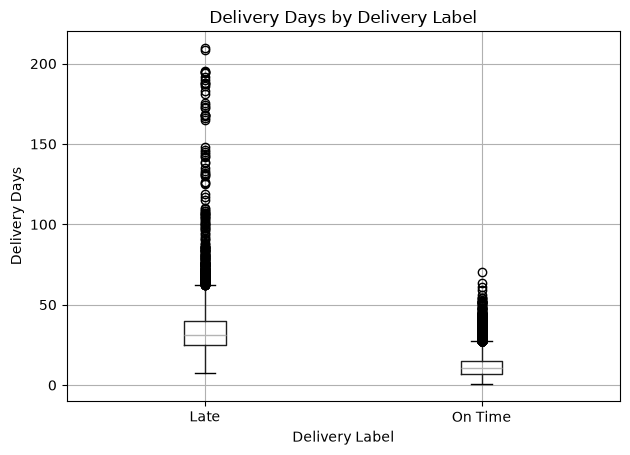

In [28]:
import matplotlib.pyplot as plt

# Save delivery days by label
train.boxplot(
    column="delivery_days",
    by="delivery_label"
)

plt.title("Delivery Days by Delivery Label")
plt.suptitle("")
plt.xlabel("Delivery Label")
plt.ylabel("Delivery Days")
plt.tight_layout()

plt.savefig("../artifacts/delivery_days_by_label.png")
plt.show()